# Level 3 — Beyond the Paper: Your Research Project

### CAJAL Neuromics 2026 · Project 15: Mapping the Spatial Cellular Architecture of the Brain

**This is the open-ended level.** Levels 1–2 walked you along a fixed path: segment cells,
QC them, annotate the atlas, reproduce the niches and cell–cell communication of Wang et al.
(2025). Now the guardrails come off. You will **pick a question the paper did not fully
answer, design an analysis, run it, and present what you found** — even if the answer is
"it's inconclusive, and here is why."

**How this level works**

- **Kernel:** in JupyterLab, select the `Spatial Brain (SIF)` kernel (top-right), the same one used in Levels 1-2.
- **Time:** the largest block of the course (~2.5 days), ending in a short mini-presentation
  to the group (the course outline allots ~15 min per project — your instructor will confirm).
- **Deliverable:** a notebook that tells a story (question → approach → figures → interpretation
  → limitations) plus a few slides. Partial and negative results are expected and valued.
- **Scaffolding:** almost none. Below is a **menu of three projects**, then **one of them worked
  end-to-end as a reference** (Project 2). Use it as a template for rigour and structure — not as
  the thing to copy. Your instructor is your collaborator; ask early and often.

> **This is the solution notebook.** It contains the project menu *and* a fully worked example
> for Project 2. The student version has the same menu and an empty workspace.

---

### ⚠️ Where data lives — read before you load anything

Several people run this level **in parallel**, so be disciplined about paths:

- **READ** the large staged objects from the **shared, read-only** project folder
  (`/shared/projects/.../C15/data/...`). Never copy them into your repo, never write to that
  folder. They are staged once and shared by everyone.
- **WRITE** every output (figures, small tables, processed subsets) into **your own repo**
  (`figures/`, `data/`) via the `FilePaths` helper. Your outputs are yours alone.
- The multiome **ATAC** object is **16 GB** — do **not** `read_h5ad` it whole on a small
  allocation. Open it `backed="r"`, subset to the cells/peaks you need, *then* load. See
  Project 1's notes.

The staged files you can draw on:

| File | Size | Contents |
|---|---|---|
| `wang2025_merfish/processed/wang2025_merfish_cells.h5ad` | 0.19 GB | **404,030 annotated MERFISH cells** (the authors' cells, post-reveal). `X`=lognorm, `layers['counts']`; `obs`: `class/subclass/type/type_updated/niches/niche_name/Region/Sample_ID/Group/age`; `obsm`: `spatial`, `X_umap`. |
| `wang2025_multiome/processed/wang2025_multiome_rna.h5ad` | 3 GB | snRNA reference, 232,328 × 33,452, `X`=lognorm, `counts`, `X_pca`. |
| `wang2025_multiome/processed/wang2025_multiome_atac.h5ad` | 16 GB | snATAC, 232,328 × 82,505 peaks, `X`=TF-IDF, peak `chrom/start/end` in `var`. **Open backed.** |
| `wang2025_multiome/processed/wang2025_multiome.h5mu` | 9.9 GB | the paired MuData (RNA+ATAC together), if you need both modalities linked. |


## The project menu

Pick **one** (or propose your own — clear it with an instructor first). Each entry lists the
**question**, the **paper loose-end** it targets, which **data** to read, a **suggested approach**
with in-environment tools, a **compute note**, and what a **good deliverable** looks like.

All three are genuinely open — the paper touches each but leaves room. Difficulty and compute
weight differ; choose to match your interest and comfort with the tooling.

---

### Project 1 — The chromatin logic of a cell lineage *(snATAC / multiome)*

**Question.** L1–L2 only ever used gene *expression*. The atlas also has **snATAC — chromatin
accessibility over the same 232,328 nuclei** — that you have not touched. For a lineage you care
about (e.g. the excitatory-neuron trajectory RG → IPC-EN → EN-Newborn → EN-IT, or the Tri-IPC →
glia branch), **which regulatory regions and transcription factors define each step?**

**Loose-end.** The paper's regulatory story rests on SCENIC+ GRNs (582 eRegulons). You will not
re-run SCENIC+, but you can rebuild its logic from the raw ingredients and ask whether the master
regulators (e.g. *PAX6/EMX2* in radial glia, *TBR1/FOXP1* in EN, *LHX6/ARX* in IN) fall out.

**Data.** `wang2025_multiome_atac.h5ad` (peaks + genomic coords) **and**
`wang2025_multiome_rna.h5ad` (same cells, same order → paired).

**Suggested approach.**
- Open ATAC `backed="r"`; subset to your lineage's cells (and, if needed, to the most variable
  peaks) *before* loading into memory. ⚠️ This is slow off the shared filesystem — in our test just
  *opening* the 16 GB file backed took ~3 min, and pulling a two-cell-type subset (~14k cells) into
  memory took ~3 min more. Subsample cells generously and be patient.
- **Marker peaks:** `sc.tl.rank_genes_groups` on the peak matrix → differentially accessible
  regions per cell type.
- **Peak → gene links:** because RNA and ATAC are the *same* cells, correlate a peak's
  accessibility with a nearby gene's expression across cells (or across metacells you build by
  averaging within cell type × age). Peaks near a gene's TSS that track its expression are
  candidate enhancers. **You supply the gene's locus** (the RNA object has gene *symbols* but no
  coordinates — grab a TSS from a genome browser / GTF); the *peak* coords are already in
  `atac.var` (`chrom/start/end`).
- **TF activity:** `decoupler` with a TF–target network (e.g. CollecTRI) on the RNA gives a
  per-cell-type TF-activity matrix — a lightweight stand-in for eRegulon activity.
- *Stretch:* full GRN inference (SCENIC+/pycisTopic) — **not in the env**; you would add it and
  expect long CPU runtimes.

**Compute.** Heaviest project — memory-careful ATAC handling is the whole game. `decoupler`
network fetch needs internet (compute nodes have it). Subsample cells generously.

**Good deliverable.** A short list of cell-type-defining peaks/TFs for your lineage, at least one
convincing peak↔gene link with a plot, and an honest read on how well the accessibility story
matches the expression story.

---

### Project 2 — The neurogenesis-to-gliogenesis switch, in space *(MERFISH)* · ⭐ worked below

**Question.** The paper's headline is the **Tri-IPC** (tripotent intermediate progenitor,
ex-"IPC-glia") that, after ~GW18, locally produces **astrocytes, OPCs, and GABAergic
interneurons** — the moment the cortex pivots from making neurons to making glia. **Can you see
this transition in the tissue?** Where do Tri-IPCs and their putative progeny sit, and how does the
picture change across the three sampled ages (2nd trimester → 3rd trimester → infancy)?

**Loose-ends (two, verbatim).**
- *"Whether these late-born EN-Newborn cells will migrate to the cortical grey matter, the
  subcortical white matter or the olfactory bulb remains to be determined."*
- On IN-NCx_dGE-Immature (MEIS2⁺/SP8⁺): *"our spatial transcriptomic data indicate that [they]
  may become white-matter interneurons … further investigation is needed."*

**Data.** `wang2025_merfish_cells.h5ad` only — small, fast, low-memory, parallel-safe.

**Suggested approach.** Compositional shift across age; spatial maps of the lineage per age;
zone (`niche_name`) occupancy; `squidpy` neighbourhood enrichment / co-occurrence to test whether
Tri-IPCs physically sit next to their progeny. **No trajectory inference needed** — you use the
three age groups as a cross-sectional developmental axis. *(Fully worked below.)*

**Compute.** Light. Everything runs comfortably on a standard allocation (the neighbourhood
permutation test is the one slow-ish step, ~1–2 min).

**Good deliverable.** A figure panel showing the lineage's spatial/zonal distribution across age,
a neighbourhood-enrichment result, and a careful statement of what a fixed snapshot can and cannot
say about *fate*.

---

### Project 3 — A disease-risk map of the developing cortex *(multiome → space)*

**Question.** The paper maps neuropsychiatric **GWAS risk** onto cell types with SCAVENGE and finds,
strikingly, that **autism (ASD) risk peaks in 2nd-trimester immature intratelencephalic (IT)
neurons**, with a temporal ordering of disorders along differentiation. **Which developing cell
types — and which tissue locations — carry the most genetic risk for a disorder you choose?**

**Loose-end (verbatim).** On the cognition associations (*RG ↔ executive function, microglia ↔
working memory*): *"The exact mechanisms underlying these associations remain to be elucidated."*

**Data.** `wang2025_multiome_rna.h5ad` (per-type risk enrichment) + `wang2025_merfish_cells.h5ad`
(project the risk score into space). You supply risk gene sets: **SFARI Gene** (ASD) and the
**GWAS Catalog** are the standard sources.

**Suggested approach.**
- Assemble a risk gene set (start with a handful of high-confidence genes; scale up to the full
  SFARI/GWAS list). Keep it in *your* repo.
- Score it across cells with `decoupler` (or `sc.tl.score_genes`) → which cell types light up?
  Do you recover ASD → immature IT neurons? On the full-transcriptome **RNA reference** this is
  solid (all your risk genes are present).
- **Project into space:** score the same set on the MERFISH cells and plot the risk on tissue.
  ⚠️ **Panel limitation — check this first.** The MERFISH panel is only 300 genes: of a typical
  ~30-gene high-confidence ASD set, we found **only 4 on the panel** (DSCAM, CNTNAP2, RELN, SATB2).
  So the spatial projection rests on a *handful* of genes and is **illustrative at best** — quantify
  the overlap for your gene set up front, and if it's tiny, lean on the RNA-reference enrichment and
  present the spatial map as suggestive only.
- Compare two disorders, or a disorder vs a non-brain control trait, to show specificity.

**Compute.** Medium. RNA (3 GB) loads fine; scoring is cheap. This is an ATAC-free take on a
SCAVENGE-style idea (no accessibility propagation) — name that simplification honestly.

**Good deliverable.** A per-cell-type risk-enrichment plot, a (caveated) spatial risk map, and a
paragraph on what the *expression*-based proxy on a 300-gene panel can and cannot claim relative to
the paper's *accessibility*-based genome-wide method.

---

### Other directions (lighter, or bring-your-own data)

If none of the three grabs you, the paper and course leave other threads open — talk to an
instructor before committing:

- **Niche robustness** — the L2 niches came from one parameter choice (k-means on 50 neighbours,
  k=10). How stable are they to knn/radius/k? Which domains survive? *(MERFISH; light; `squidpy`.)*
- **A second reference** — annotate the MERFISH cohort with an *independent* developing-cortex atlas
  and compare concordance to the L2 labels. *(Needs an external reference staged.)*
- **Spatial denoising** — reference-based correction of transcript spillover (e.g. **SPLIT**,
  CPU-friendly), evaluated with the **L1 negative-marker purity metric** (import it from
  `analysis/level1/l1_utils.py` rather than re-deriving).
- **Tri-IPC ↔ glioblastoma** — the paper shows >half of GBM malignant cells resemble Tri-IPCs. Map
  the Tri-IPC signature onto an external **glioblastoma** dataset for a disease angle. *(Needs a GBM
  reference downloaded to the shared folder — ask an instructor; not staged yet.)*

---

> The rest of this notebook works **Project 2** end to end, as a reference for the depth and
> structure we expect. Your project does not need to look like this one — but it should be this
> deliberate about **what it claims and what it cannot.**


# ⭐ Worked example — Project 2: the neurogenesis-to-gliogenesis switch, in space

**The biology.** Early in cortical development, radial glia (RG) make excitatory neurons via
IPC-EN. Around GW18 a new progenitor appears — the **Tri-IPC** — that is *tripotent*: in culture
and after transplantation it produces **astrocytes, OPCs (oligodendrocyte lineage), and GABAergic
interneurons**. Wang et al. argue this marks the **neurogenesis → gliogenesis transition**. Most of
their evidence is molecular and *in vitro*; the **spatial** picture is thinner.

**Our question.** Using only the annotated MERFISH cohort, can we see this transition in intact
tissue? Concretely:

1. Does the **balance of neurogenic vs gliogenic cells shift** across the three ages?
2. **Where** do Tri-IPCs and their putative progeny sit — germinal zones? white matter?
3. Do Tri-IPCs **physically neighbour** their progeny (spatial evidence *consistent with* local
   production)?
4. Do **IN-NCx_dGE-Immature** cells move toward **white matter** with age, as the paper's loose-end
   suggests?

We deliberately **do not** attempt fate/trajectory inference — a fixed snapshot cannot follow a
cell forward in time. We treat the three age groups as a **cross-sectional** developmental axis and
lean on **composition** and **spatial neighbourhood** statistics.


## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

from spatialbrain import FilePaths

sc.settings.verbosity = 1
sc.set_figure_params(dpi=90, frameon=False, figsize=(5, 4))
%matplotlib inline

# Read-only staged data (shared across everyone) — never write here.
# NB: we hardcode the absolute shared path on purpose. FilePaths.dataset() resolves to *this
# repo's* data/ (project convention), not the shared project root — so FilePaths is the right tool
# for the WRITE target below, but not for READING the staged objects.
MERFISH = (
    "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/"
    "data/wang2025_merfish/processed/wang2025_merfish_cells.h5ad"
)
# Write outputs into *your* repo.
FIG = FilePaths.FIGURES / "level3"
FIG.mkdir(parents=True, exist_ok=True)
print("figures ->", FIG)

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


figures -> /shared/home/tp185001/github/cajal-project15-spatial-brain/figures/level3


In [2]:
adata = sc.read_h5ad(MERFISH)
print(adata)

AnnData object with n_obs × n_vars = 404030 × 300
    obs: 'orig.ident', 'nCount_Vizgen', 'nFeature_Vizgen', 'z', 'volume', 'fov', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ID', 'Estimated_postconceptional_age_in_days', 'Group', 'Region', 'Region_details', 'integrated_snn_res.2.8', 'class', 'subclass', 'type', 'nCount_niche', 'nFeature_niche', 'niches', 'niche_name', 'type_updated'
    uns: 'pca'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'


Two categorical columns do the heavy lifting here:

- **`type_updated`** — the authors' final cell-type labels, including the renamed **`Tri-IPC`**
  and **`IN-NCx_dGE-Immature`**.
- **`niche_name`** — each cell's spatial niche, which maps onto a **histological zone** (VZ/SVZ,
  intermediate zone, white matter, the cortical layers, dLGE).

Let's fix a sensible age order and define the cell groups we care about.

In [3]:
# Impose a developmental order on the age groups (categorical order is not guaranteed).
AGE_ORDER = ["Second_trimester", "Third_trimester", "Infancy"]
adata.obs["Group"] = pd.Categorical(adata.obs["Group"], categories=AGE_ORDER, ordered=True)

# The Tri-IPC lineage: the tripotent progenitor + its three progeny fates.
GLIOGENIC = [
    "Tri-IPC",  # the progenitor
    "OPC",
    "Oligodendrocyte-Immature",  # oligodendrocyte fate
    "Astrocyte-Protoplasmic",
    "Astrocyte-Fibrous",  # astrocyte fate
    "IN-NCx_dGE-Immature",  # interneuron fate
]
# The neurogenic programme it succeeds, for contrast.
NEUROGENIC = ["IPC-EN", "EN-Newborn"]

present = set(adata.obs["type_updated"].unique())
print("gliogenic present:", [c for c in GLIOGENIC if c in present])
print("neurogenic present:", [c for c in NEUROGENIC if c in present])
print("\nsamples x age:")
print(pd.crosstab(adata.obs["Sample_ID"], adata.obs["Group"]))

gliogenic present: ['Tri-IPC', 'OPC', 'Oligodendrocyte-Immature', 'Astrocyte-Protoplasmic', 'Astrocyte-Fibrous', 'IN-NCx_dGE-Immature']
neurogenic present: ['IPC-EN', 'EN-Newborn']

samples x age:
Group             Second_trimester  Third_trimester  Infancy
Sample_ID                                                   
ARKFrozen-62-PFC             51074                0        0
NIH-4365-BA10                    0            52483        0
UCSF2018-003-MFG                 0                0    47632
ARKFrozen-65-V1             169905                0        0
NIH-5900-BA17                    0            56343        0
NIH-4392-BA17                    0                0    26593


## 1. Does the neurogenic → gliogenic balance shift with age?

The simplest read on the transition: as development proceeds, the cortex should contain
**proportionally more glial-lineage cells and fewer active neurogenic progenitors.** We do not need
space for this — just composition by age.

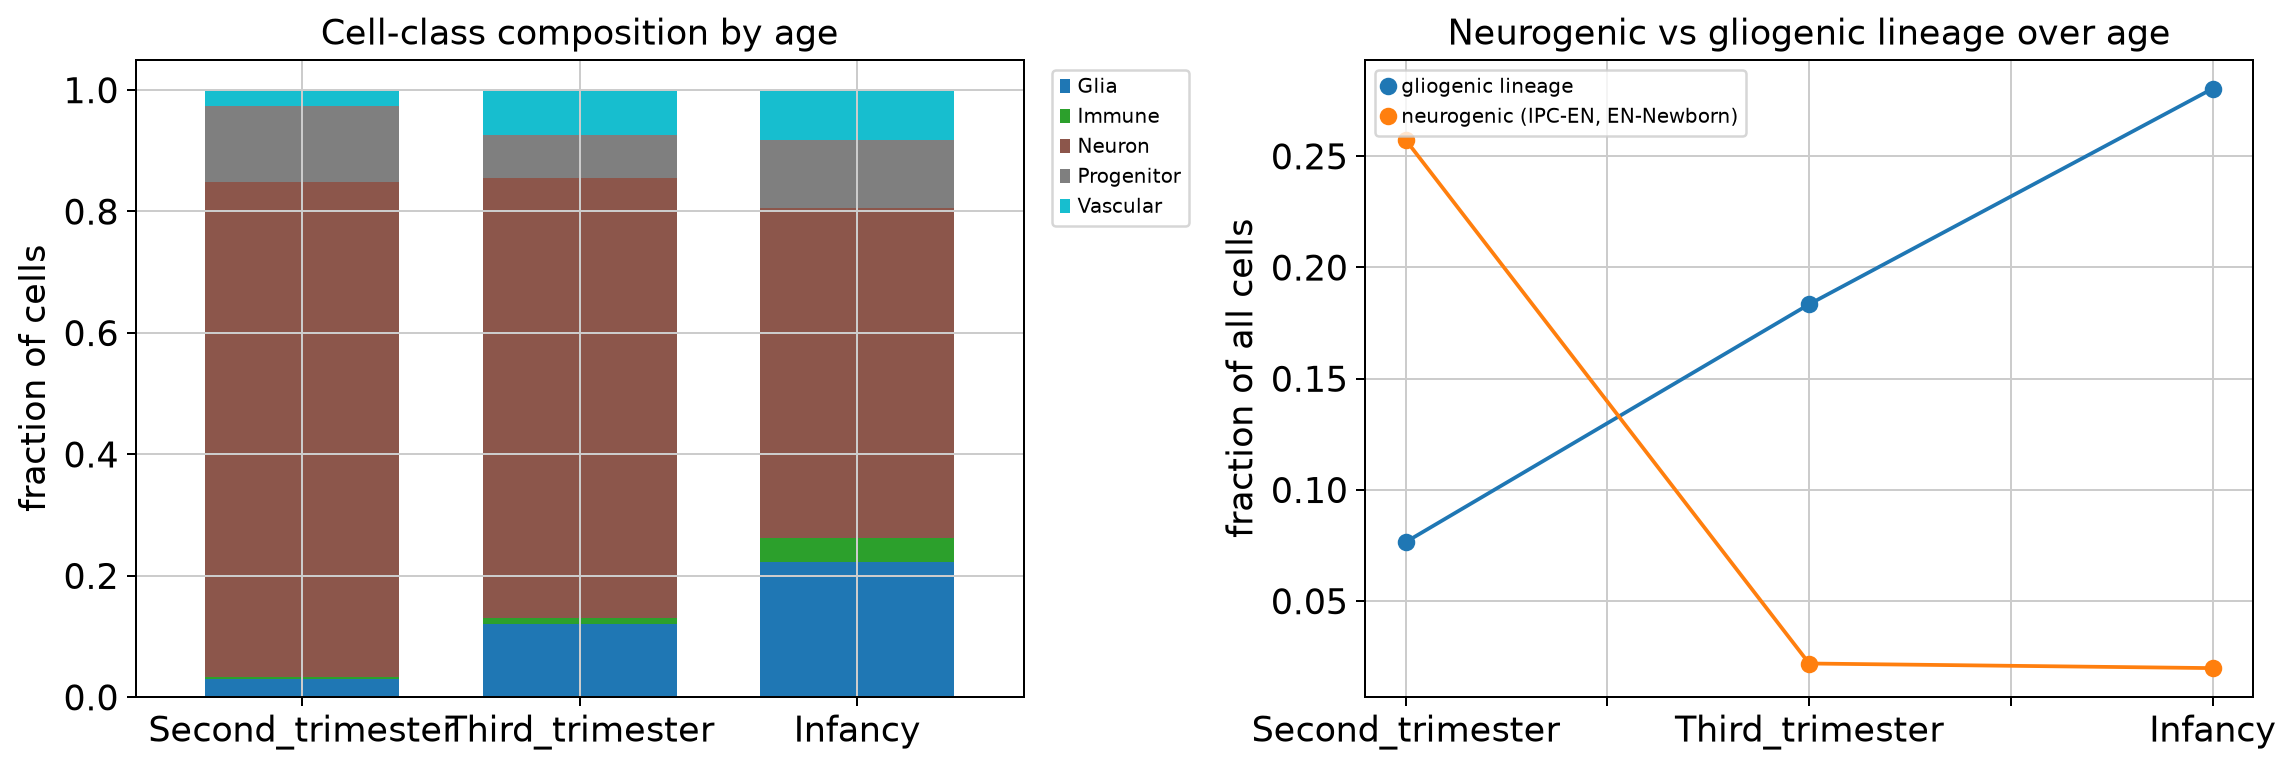

,gliogenic lineage,"neurogenic (IPC-EN, EN-Newborn)"
Group,,
Second_trimester,0.076,0.257
Third_trimester,0.183,0.022
Infancy,0.280,0.020


In [4]:
# Broad class composition per age, and the two lineage fractions we care about.
obs = adata.obs
is_glio = obs["type_updated"].isin(GLIOGENIC)
is_neuro = obs["type_updated"].isin(NEUROGENIC)

comp = pd.crosstab(obs["Group"], obs["class"], normalize="index").reindex(AGE_ORDER)
frac = pd.DataFrame(
    {
        "gliogenic lineage": is_glio.groupby(obs["Group"], observed=True).mean(),
        "neurogenic (IPC-EN, EN-Newborn)": is_neuro.groupby(obs["Group"], observed=True).mean(),
    }
).reindex(AGE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
comp.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10", width=0.7)
axes[0].set(title="Cell-class composition by age", ylabel="fraction of cells", xlabel="")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[0].tick_params(axis="x", rotation=0)

frac.plot(marker="o", ax=axes[1])
axes[1].set(title="Neurogenic vs gliogenic lineage over age", ylabel="fraction of all cells", xlabel="")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "p2_composition_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
frac.round(3)

🔬 **What to look for.** The gliogenic-lineage fraction **rises** from 2nd trimester to infancy
while the actively-neurogenic IPC-EN/EN-Newborn fraction **collapses** — the compositional signature of
the switch. (The overall `Glia` class rising is the same story at coarser resolution.)

That looks clean — maybe *too* clean. Before believing a **developmental** trend, confront the
confound: each age group is a different set of sections from different cortical areas. Let's split the
signal by area.

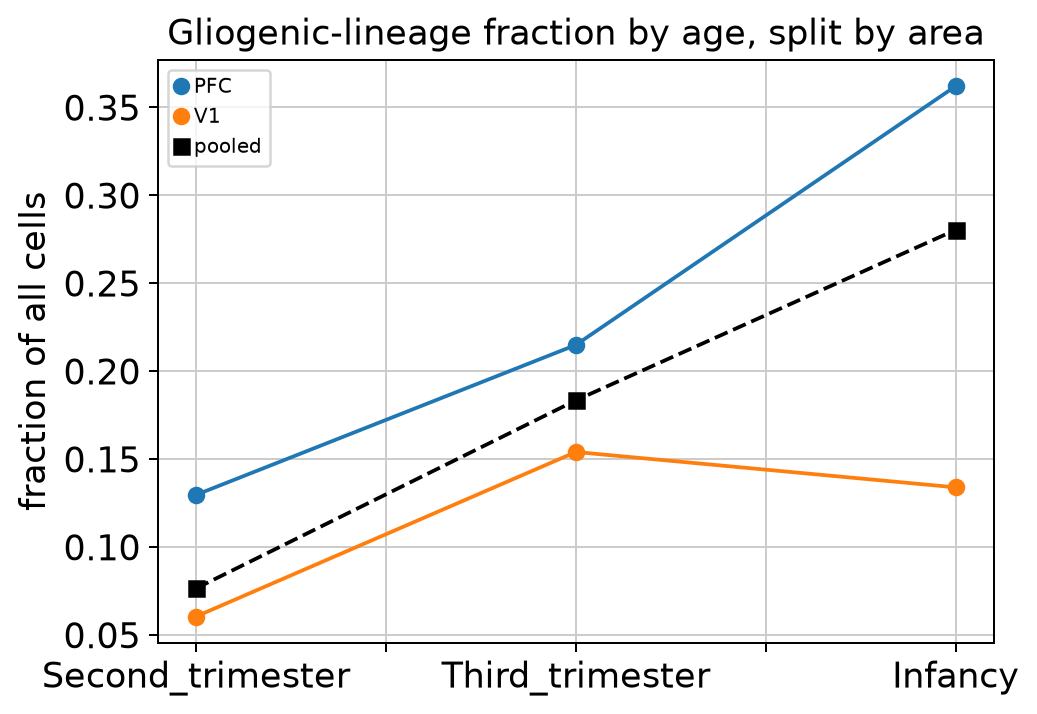

cells per age x region:
Region              PFC      V1
Group                          
Second_trimester  51074  169905
Third_trimester   52483   56343
Infancy           47632   26593


Region,PFC,V1
Group,,
Second_trimester,0.130,0.060
Third_trimester,0.215,0.154
Infancy,0.362,0.134


In [5]:
# Is the trend development, or area? Split the gliogenic fraction by age x region.
glio_by_region = (
    is_glio.groupby([obs["Group"], obs["Region"]], observed=True).mean().unstack("Region").reindex(AGE_ORDER)
)

fig, ax = plt.subplots(figsize=(6, 4.2))
glio_by_region.plot(marker="o", ax=ax)
frac["gliogenic lineage"].plot(marker="s", ls="--", color="k", ax=ax, label="pooled")
ax.set(title="Gliogenic-lineage fraction by age, split by area", ylabel="fraction of all cells", xlabel="")
ax.legend(title="", fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "p2_composition_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

print("cells per age x region:")
print(pd.crosstab(obs["Group"], obs["Region"]).reindex(AGE_ORDER))
glio_by_region.round(3)

❓ **The confound, made explicit.** Read the split carefully:

- In **PFC** the gliogenic fraction rises monotonically (~0.13 → 0.22 → 0.36) — a clean switch.
- In **V1** it **rises then falls** (~0.06 → 0.15 → 0.13) — *not* monotonic.

The tidy pooled curve is partly an **artifact of which area dominates each age bin** (the 2nd-trimester
bin is ~77% V1; the infancy bin's largest section is PFC). So "the cortex makes more glia with age" is
well supported **in PFC**, but the pooled magnitude oversells it, and the story differs by area. This is
the kind of entanglement your own project must surface — in six sections, **age, area, donor and section
are all confounded.** Whenever you show a trend across `Group`, ask which sections and areas drive it.

## 2. Where do Tri-IPCs and their progeny sit?

Now we use space. Classical *neurogenesis* (RG → IPC-EN → EN) happens at the ventricular surface, in
the **ventricular/subventricular zone (VZ/SVZ)**. Does the **gliogenic** lineage sit in the same place,
or somewhere else? For one representative section per age group we plot the tissue and highlight the
Tri-IPC lineage.

⚠️ **Read these panels cautiously.** The representative sections are chosen by size, and they turn out
to be **V1, V1, and PFC** respectively — so the infancy panel is a *different cortical area*, not just a
later age. Treat the three panels as separate snapshots, not a clean time-lapse.

In [6]:
# Pick the section with the most cells in each age group as the representative.
rep = adata.obs.groupby("Group", observed=True)["Sample_ID"].agg(lambda s: s.value_counts().idxmax()).reindex(AGE_ORDER)
print("representative section per age:")
print(rep)

representative section per age:
Group
Second_trimester     ARKFrozen-65-V1
Third_trimester        NIH-5900-BA17
Infancy             UCSF2018-003-MFG
Name: Sample_ID, dtype: category
Categories (6, object): ['ARKFrozen-62-PFC', 'NIH-4365-BA10', 'UCSF2018-003-MFG', 'ARKFrozen-65-V1', 'NIH-5900-BA17', 'NIH-4392-BA17']


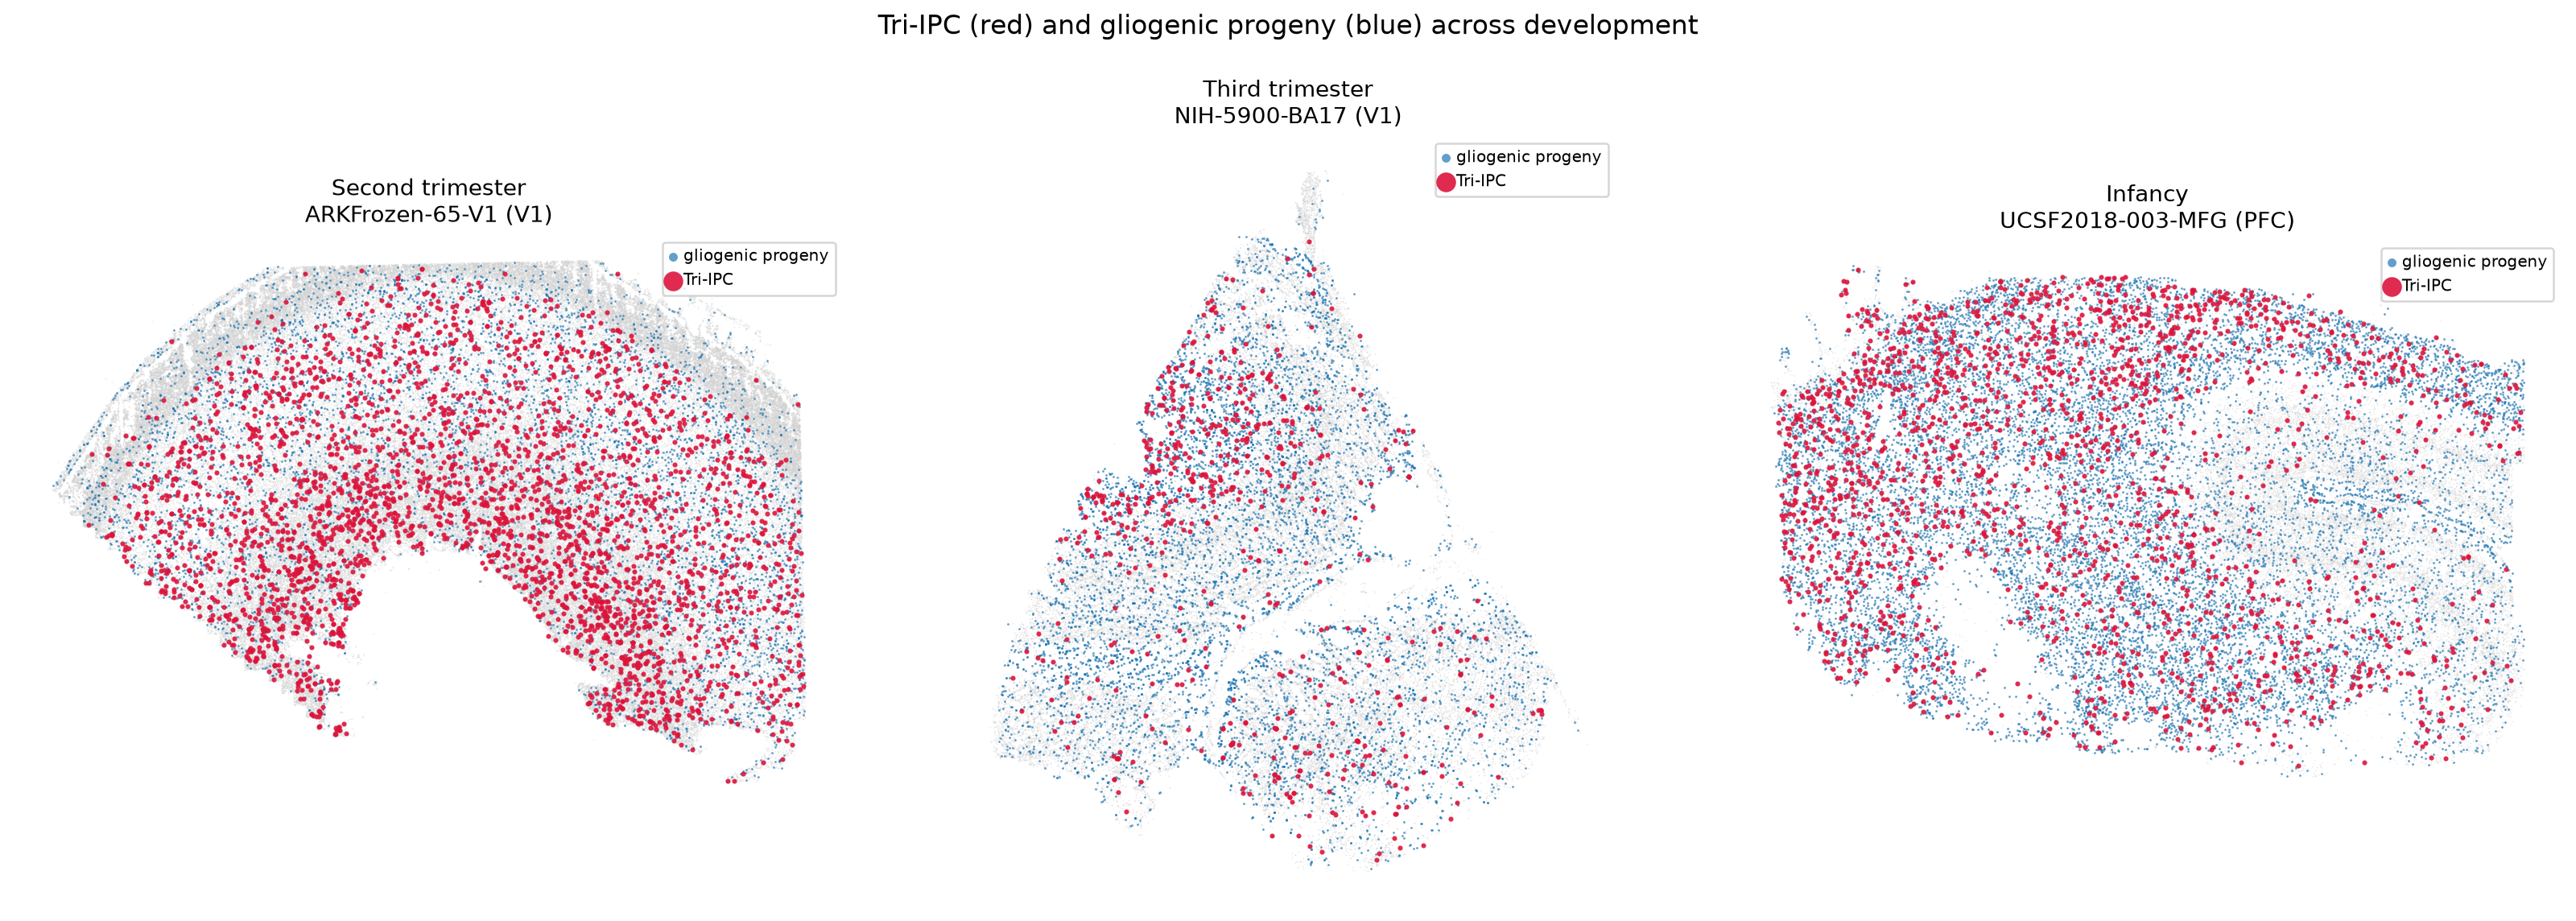

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))

for ax, age in zip(axes, AGE_ORDER, strict=False):
    sid = rep[age]
    sub = adata[(adata.obs["Sample_ID"] == sid)]
    xy = sub.obsm["spatial"]
    is_glio_s = sub.obs["type_updated"].isin(GLIOGENIC).values
    is_triipc = (sub.obs["type_updated"] == "Tri-IPC").values

    # background: all cells, faint
    ax.scatter(xy[:, 0], xy[:, 1], s=0.4, c="lightgrey", alpha=0.5, linewidths=0)
    # gliogenic progeny
    ax.scatter(
        xy[is_glio_s & ~is_triipc, 0],
        xy[is_glio_s & ~is_triipc, 1],
        s=1.2,
        c="tab:blue",
        alpha=0.7,
        linewidths=0,
        label="gliogenic progeny",
    )
    # Tri-IPC on top
    ax.scatter(xy[is_triipc, 0], xy[is_triipc, 1], s=6, c="crimson", alpha=0.9, linewidths=0, label="Tri-IPC")

    ax.set_title(f"{age.replace('_', ' ')}\n{sid} ({sub.obs['Region'].iloc[0]})", fontsize=11)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")
    ax.legend(markerscale=4, fontsize=8, loc="upper right")

plt.suptitle("Tri-IPC (red) and gliogenic progeny (blue) across development", fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "p2_spatial_maps.png", dpi=150, bbox_inches="tight")
plt.show()

🔬 **What to look for.** The lineage is **not** a thin band at the ventricular surface — Tri-IPCs
and their progeny spread through the tissue and (as we quantify next) sit largely in the **white matter
and intermediate zone**, not only the VZ/SVZ. Section orientation varies, so it's the *relative*
arrangement that matters; and remember the third panel is a different area.

💡 **Tip.** MERFISH `spatial` is in microns; we `invert_yaxis()` so images read the conventional way.
Overlay an **on-panel** marker if you like — `EGFR` (Tri-IPC), `PDGFRA` (OPC), `AQP4` (astrocyte),
`SP8` (the interneuron) — using the next cell's helper.

In [8]:
# Optional marker sanity check: are canonical markers on the 300-gene panel?
for g in ["EGFR", "OLIG2", "MEIS2", "SP8", "AQP4", "PDGFRA"]:
    print(f"{g:8s} on panel: {g in adata.var_names}")

EGFR     on panel: True
OLIG2    on panel: False
MEIS2    on panel: False
SP8      on panel: True
AQP4     on panel: True
PDGFRA   on panel: True


Note two of these six — `OLIG2` and `MEIS2` — are **off the panel**. The 300-gene MERFISH panel is
a deliberate subset, so some canonical markers simply are not measured; that is a concrete instance of
the limitation we return to in §6. Lean on the on-panel markers above (`EGFR` is the single most
Tri-IPC-specific gene on this panel).

## 3. Which zones does the lineage occupy, and how does that change?

The spatial maps are qualitative. `niche_name` gives every cell a **zone**, so we can quantify
*where* the lineage lives and how the distribution moves across age.

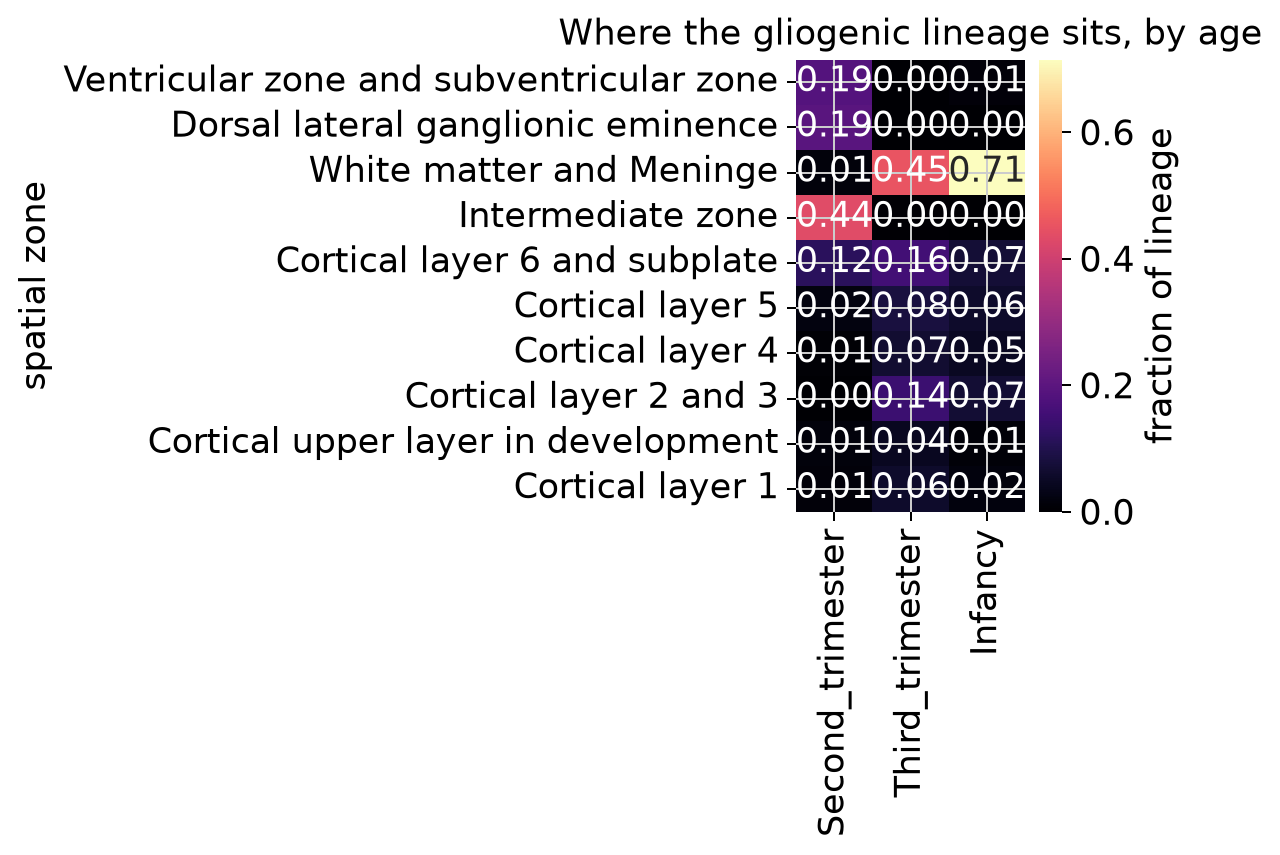

In [9]:
# Order zones roughly ventricle -> pia for readability.
ZONE_ORDER = [
    "Ventricular zone and subventricular zone",
    "Dorsal lateral ganglionic eminence",
    "White matter and Meninge",
    "Intermediate zone",
    "Cortical layer 6 and subplate",
    "Cortical layer 5",
    "Cortical layer 4",
    "Cortical layer 2 and 3",
    "Cortical upper layer in development",
    "Cortical layer 1",
]
zone_order = [z for z in ZONE_ORDER if z in set(adata.obs["niche_name"].unique())]

glio = adata[adata.obs["type_updated"].isin(GLIOGENIC)].copy()

# For each age, what fraction of gliogenic-lineage cells is in each zone?
occ = pd.crosstab(glio.obs["niche_name"], glio.obs["Group"], normalize="columns").reindex(
    index=zone_order, columns=AGE_ORDER
)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(occ, cmap="magma", annot=True, fmt=".2f", cbar_kws={"label": "fraction of lineage"}, ax=ax)
ax.set(title="Where the gliogenic lineage sits, by age", xlabel="", ylabel="spatial zone")
plt.tight_layout()
plt.savefig(FIG / "p2_zone_occupancy.png", dpi=150, bbox_inches="tight")
plt.show()

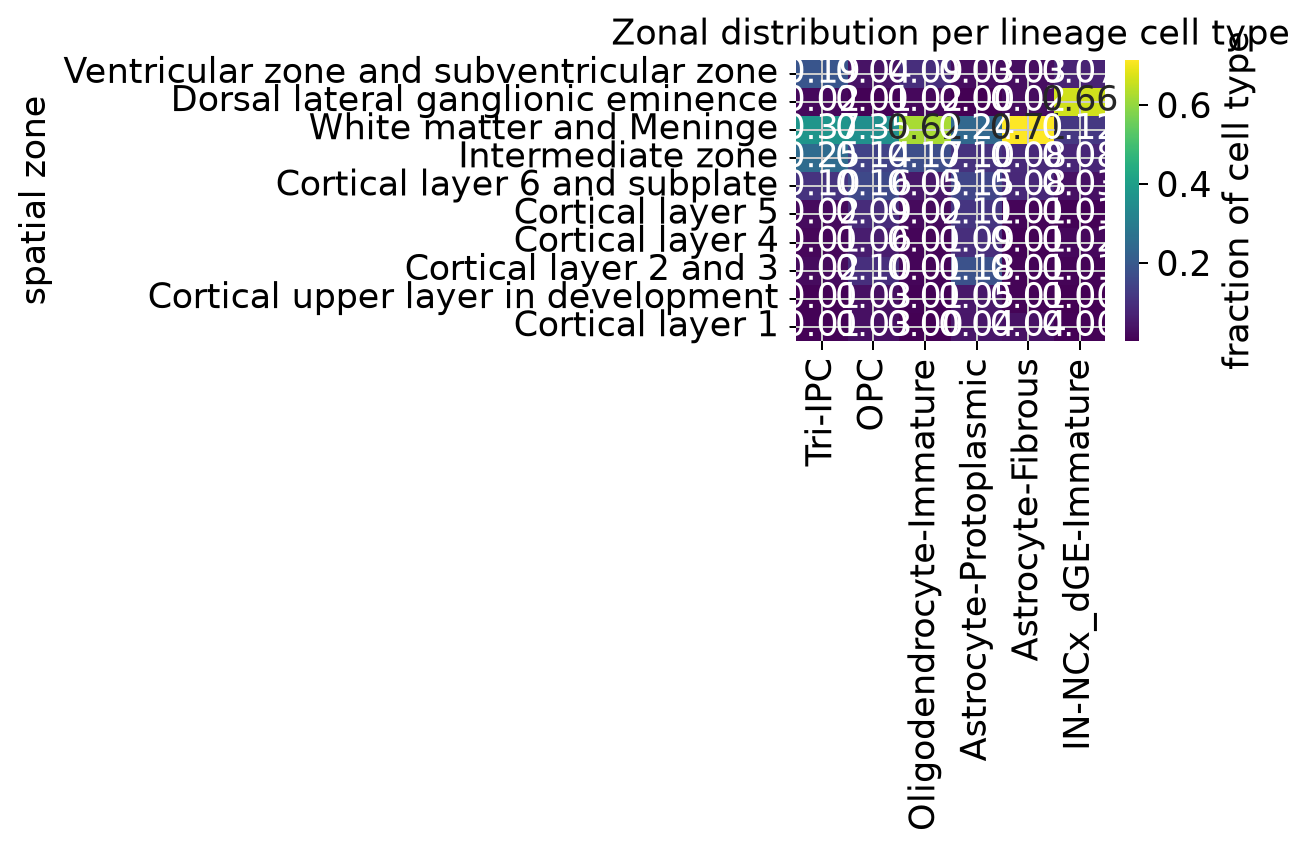

In [10]:
# Break it down per cell type (pooled over age) — do the fates occupy different zones?
per_type = pd.crosstab(adata.obs["niche_name"], adata.obs["type_updated"], normalize="columns").reindex(
    index=zone_order, columns=[c for c in GLIOGENIC if c in present]
)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(per_type, cmap="viridis", annot=True, fmt=".2f", cbar_kws={"label": "fraction of cell type"}, ax=ax)
ax.set(title="Zonal distribution per lineage cell type", xlabel="", ylabel="spatial zone")
plt.tight_layout()
plt.savefig(FIG / "p2_zone_per_type.png", dpi=150, bbox_inches="tight")
plt.show()

🔬 **What to look for (and what actually shows up).** Read the heatmaps against your expectations:

- **Tri-IPC** does *not* sit mainly in the VZ/SVZ — its plurality is in the **white matter** (~0.37),
  then the **intermediate zone** (~0.25), with VZ/SVZ only third (~0.19). The gliogenic progenitor lives
  in the subgerminal compartments, not the ventricular edge.
- **OPCs and astrocytes** spread through white matter, the intermediate zone and the layers.
- **IN-NCx_dGE-Immature** is dominated (pooled over age) by the **dorsal LGE** (~0.66) — its germinal
  origin — *not* white matter. Its white-matter signal is real but **age-dependent**, which is exactly
  the loose-end we unpack in §5.

❓ **Question.** Where does the lineage's mass actually sit, and does it shift with age? (Careful: the
`niches` collapse the human outer SVZ into a single "VZ/SVZ" label, so the "white matter / intermediate
zone" territory here includes subventricular regions a finer annotation might split out.)

## 4. Do Tri-IPCs physically neighbour their progeny?

If Tri-IPCs produce glia and interneurons **locally**, their progeny should be spatial neighbours
more often than chance. `squidpy` tests exactly this: build a spatial graph, then
`nhood_enrichment` permutes labels to score which cell-type pairs are adjacent more (or less) than
expected. We run it on one representative section (spatial coordinates are only meaningful within a
section). *(This permutation test is the heaviest cell in the notebook — expect ~1–2 min.)*

In [11]:
sid = rep["Second_trimester"]  # richest in progenitors -> best chance to see local production
sec = adata[adata.obs["Sample_ID"] == sid].copy()
sec.obs["type_updated"] = sec.obs["type_updated"].cat.remove_unused_categories()
print(f"section {sid}: {sec.n_obs:,} cells, {sec.obs['type_updated'].cat.categories.size} types")

# Spatial graph on the physical coordinates (generic = use obsm['spatial']).
sq.gr.spatial_neighbors(sec, coord_type="generic", n_neighs=6)
sq.gr.nhood_enrichment(sec, cluster_key="type_updated", n_perms=100, seed=0, show_progress_bar=False)

section ARKFrozen-65-V1: 169,905 cells, 29 types


/tmp/slurm_tp185001_419041.tmp/ipykernel_1471562/603550799.py:7: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(sec, coord_type="generic", n_neighs=6)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


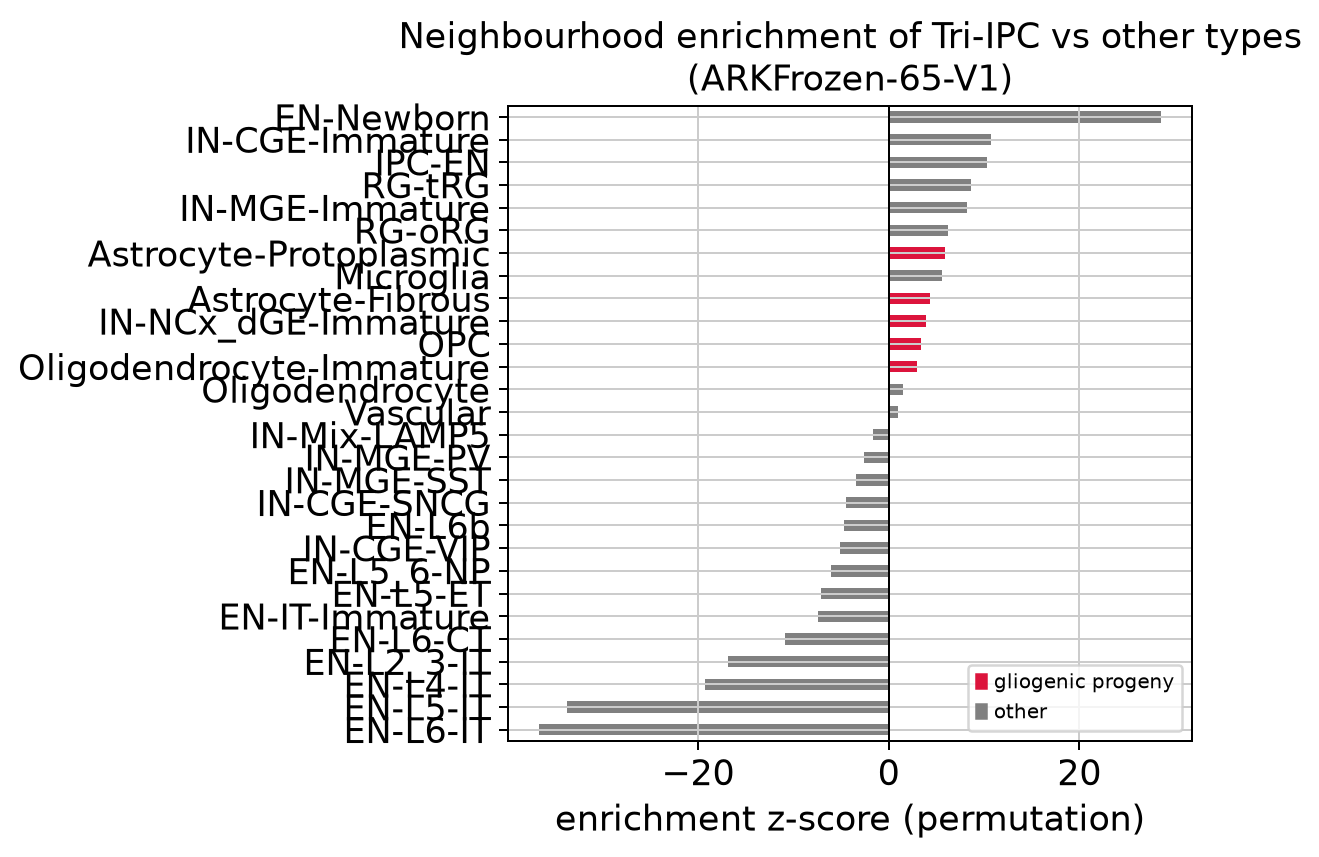

Tri-IPC neighbourhood z-scores (progeny):
Astrocyte-Protoplasmic      6.0
Astrocyte-Fibrous           4.3
IN-NCx_dGE-Immature         4.0
OPC                         3.3
Oligodendrocyte-Immature    3.0
Name: Tri-IPC, dtype: float64


In [12]:
# Pull the z-score matrix and show Tri-IPC's enrichment against every type.
cats = list(sec.obs["type_updated"].cat.categories)
z = pd.DataFrame(sec.uns["type_updated_nhood_enrichment"]["zscore"], index=cats, columns=cats)

tri_row = z.loc["Tri-IPC"].drop("Tri-IPC").sort_values(ascending=False)
progeny = [c for c in GLIOGENIC if c in cats and c != "Tri-IPC"]

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["crimson" if t in progeny else "grey" for t in tri_row.index]
tri_row.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="k", lw=0.8)
ax.set(title=f"Neighbourhood enrichment of Tri-IPC vs other types\n({sid})", xlabel="enrichment z-score (permutation)")
ax.invert_yaxis()
from matplotlib.patches import Patch

ax.legend(
    handles=[Patch(color="crimson", label="gliogenic progeny"), Patch(color="grey", label="other")],
    fontsize=8,
    loc="lower right",
)
plt.tight_layout()
plt.savefig(FIG / "p2_nhood_triipc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Tri-IPC neighbourhood z-scores (progeny):")
print(tri_row[tri_row.index.isin(progeny)].round(1))

🔬 **What to look for.** Positive z-scores between **Tri-IPC** and its progeny (OPC, astrocytes,
IN-NCx_dGE-Immature) mean they sit together more than chance — spatial evidence *consistent with* local
production. (We ran one section; it's worth re-running on another to confirm it replicates — it does.)
Watch for the honest complication: Tri-IPCs also neighbour **RG** and **IPC-EN** strongly, simply
because all progenitors share the crowded germinal/subgerminal territory. Co-location in a shared niche
is **not** proof of a lineage relationship — see the reflection.

💡 **Extend.** `sq.gr.co_occurrence(sec, cluster_key="type_updated")` gives enrichment as a function of
*distance*, which separates "same niche" (enriched at all scales) from "direct contact" (enriched only
at short range).

## 5. The interneuron loose-end: do dLGE interneurons move into white matter?

**IN-NCx_dGE-Immature** (MEIS2⁺/SP8⁺) are born in the **dorsal lateral ganglionic eminence (dLGE)** —
and, pooled over age, that is where most of them still sit (§3). The paper flags them as *possibly*
becoming **white-matter interstitial interneurons**, but says *"further investigation is needed."* A
snapshot cannot track migration, but it can ask a weaker question: does the population's zone **shift
from dLGE toward white matter as age increases**, and do meaningful numbers remain?

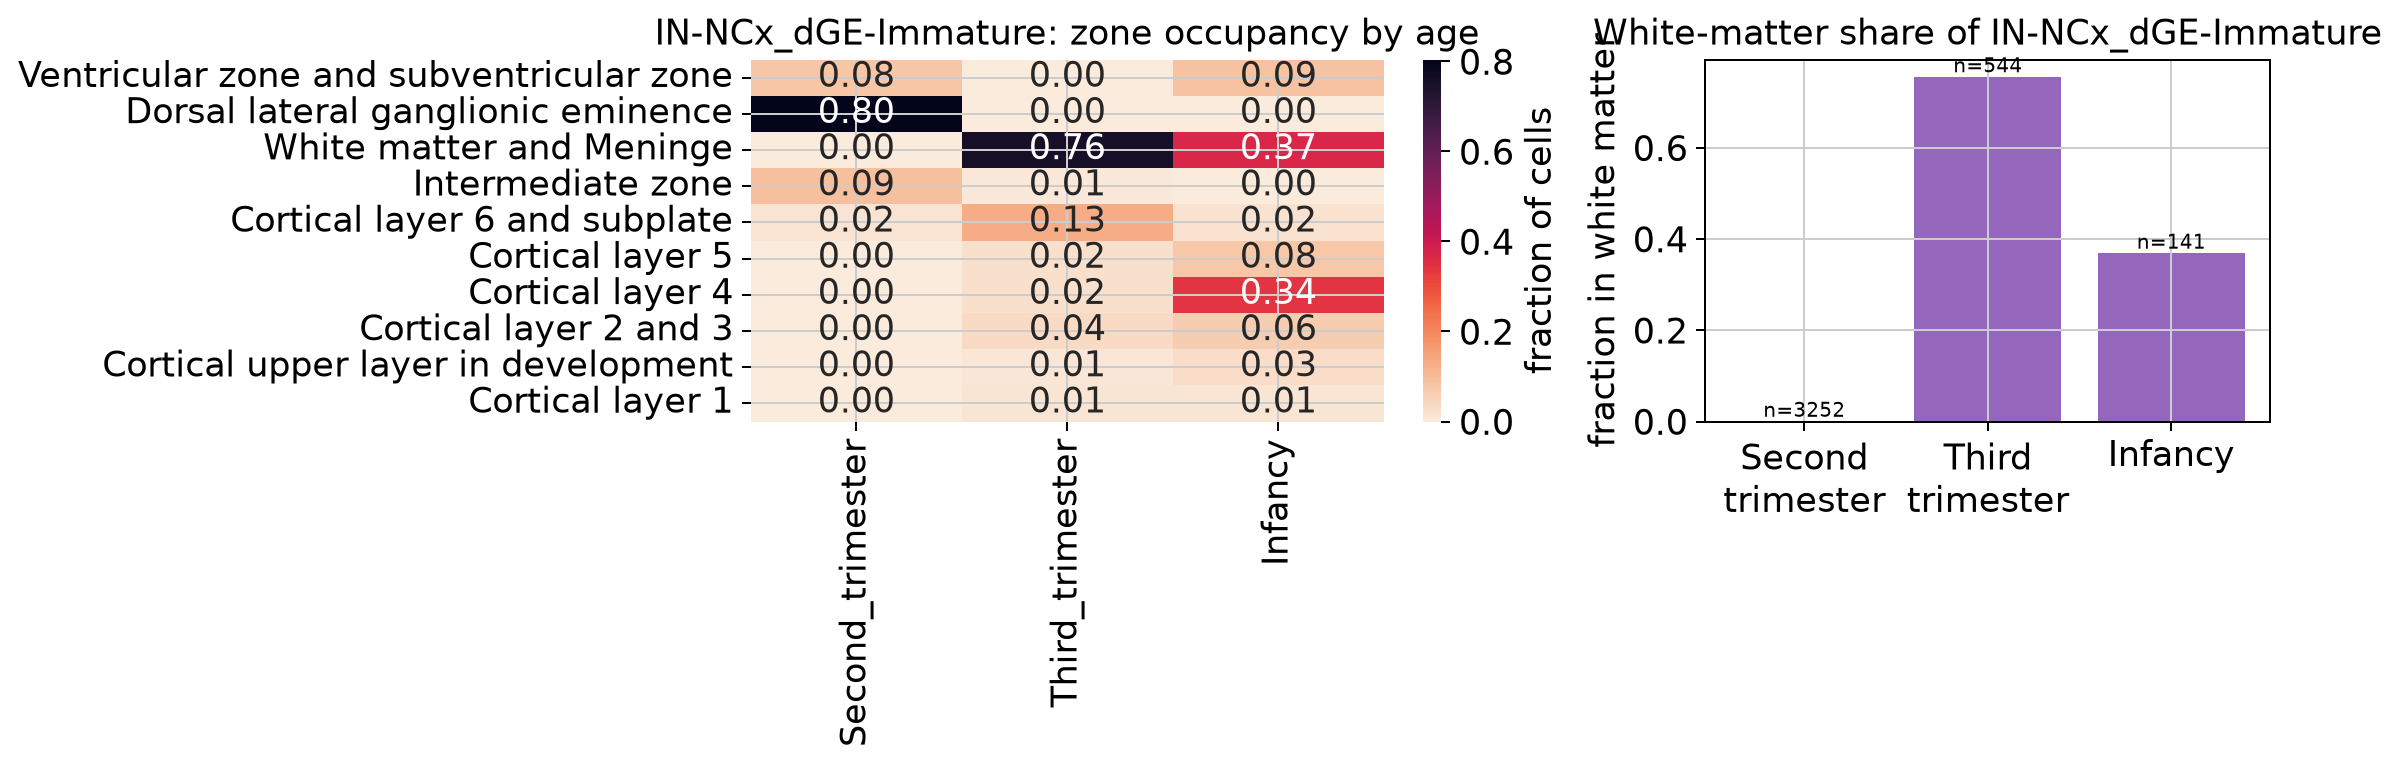

In [13]:
ct = "IN-NCx_dGE-Immature"
# Fraction of this type residing in each zone, per age.
sub = adata[adata.obs["type_updated"] == ct]
wm = "White matter and Meninge"
by_age = pd.crosstab(sub.obs["Group"], sub.obs["niche_name"], normalize="index").reindex(
    index=AGE_ORDER, columns=zone_order
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.4, 1]})
sns.heatmap(by_age.T, cmap="rocket_r", annot=True, fmt=".2f", ax=axes[0], cbar_kws={"label": "fraction of cells"})
axes[0].set(title=f"{ct}: zone occupancy by age", xlabel="", ylabel="")

# White-matter share of this type over age, with cell counts for context.
wm_share = by_age[wm]
n = sub.obs.groupby("Group", observed=True).size().reindex(AGE_ORDER)
axes[1].bar(range(len(AGE_ORDER)), wm_share.values, color="tab:purple")
for i, (v, c) in enumerate(zip(wm_share.values, n.values, strict=False)):
    axes[1].text(i, v + 0.01, f"n={c}", ha="center", fontsize=8)
axes[1].set_xticks(range(len(AGE_ORDER)))
axes[1].set_xticklabels([a.replace("_", "\n") for a in AGE_ORDER])
axes[1].set(title=f"White-matter share of {ct}", ylabel="fraction in white matter")
plt.tight_layout()
plt.savefig(FIG / "p2_interneuron_wm.png", dpi=150, bbox_inches="tight")
plt.show()

❓ **Question — and a caution about small numbers.** The white-matter *share* does climb with age
(near-zero in 2nd trimester → the majority by 3rd trimester). But watch the `n=` labels: by **infancy
there are only ~140 of these cells**, and their white-matter share is nearly tied with cortical layer 4
— close to noise. So the data are **consistent with** a dLGE → white-matter shift, but the numbers are
far too thin to call it a *persistent* white-matter interneuron population. That is the honest
resolution: a suggestive trend the snapshot cannot settle — exactly the paper's "further investigation
is needed." State which way your data leans, and how far you'd trust it.

## 6. What can this snapshot actually claim?

Be ruthless about this in your own project — it is where the marks (and the science) are.

- **Snapshots are not trajectories.** We never followed a cell. "Tri-IPCs sit next to OPCs" is
  consistent with local production but equally consistent with independent cells sharing a niche.
  Co-location ≠ lineage.
- **Age is confounded with area, individual and section.** We saw this directly in §1: the pooled
  gliogenic trend is monotonic in PFC but not in V1, and each age group is one or two sections from
  different donors. More sections per age/area would be needed to separate these.
- **The panel is 300 genes.** Cell-type labels are the authors' (transferred through their full
  transcriptome); we inherit their definitions and their errors, and two canonical markers we reached
  for (`OLIG2`, `MEIS2`) aren't even measured.
- **What would settle it?** Lineage tracing / live imaging / birth-dating — experiments, not more
  computation. Naming the experiment that *would* answer the question is part of a good write-up.

**Compare to the paper.** Wang et al. reached the fate claims with *in vitro* differentiation,
clonal analysis, and transplantation — orthogonal to this spatial snapshot. Where does your spatial
read agree with their model, and where can it simply not adjudicate?

---

# Your turn — planning template

Copy this into your own project section and fill it in **before** you write much code. A crisp plan
beats a big pile of exploratory cells.

**Project chosen:** _P1 / P2 / P3 / my own_

**Question (one sentence):** _…_

**Why it's open (the loose-end):** _…_

**Data I will read (exact files, read-only):** _…_

**Approach & tools (bullet the steps):**
- _…_

**What a positive result looks like — and a negative one:** _…_

**Biggest risk / thing most likely to go wrong:** _…_

---

## Presentation & write-up

Wrap up with a short mini-presentation to the group (the course outline allots ~15 min; your
instructor will confirm the format). A good arc:

1. **The question** and why the paper left it open (1 slide).
2. **Approach** — the data and the key method, briefly (1 slide).
3. **Results** — your two or three best figures, and what they show (2–3 slides).
4. **Interpretation & limits** — what you can and cannot claim (1 slide). *This is the most
   important slide.*
5. **What next** — the experiment or analysis that would actually settle it (1 slide).

Negative and partial results are genuinely valued: a clear "here's why the data can't answer this,
and here's what would" is a strong outcome.
